# Análisis de características de audio (Spotify Tracks Dataset)

## 0.1. Introducción

El objetivo de este proyecto es analizar qué características de audio influyen en la popularidad de una canción en Spotify.

A partir de este análisis, se desarrollarán modelos de machine learning capaces de predecir la popularidad de una pista y clasificar si una canción puede considerarse un “hit”.

Este problema combina análisis exploratorio, regresión, clasificación e interpretación de modelos.

## 0.2. Descripción del dataset

El dataset utilizado contiene información de pistas de Spotify con características de audio detalladas.

- Número de observaciones: ~114,000 pistas
- Unidad de análisis: 1 fila = 1 pista

El dataset incluye metadatos de pistas (nombre, artista, álbum) y métricas detalladas de características de audio calculadas por los algoritmos de análisis de audio de Spotify.

## 0.3. Características de audio

El dataset contiene las siguientes características de audio clave:

- **Acousticness (acusticidad)**: medida de confianza de si la pista es acústica (0.0 - 1.0)
- **Danceability (bailabilidad)**: idoneidad de una pista para bailar (0.0 - 1.0)
- **Energy (energía)**: intensidad y nivel de actividad (0.0 - 1.0)
- **Instrumentalness (instrumentalidad)**: probabilidad de que la pista sea instrumental (0.0 - 1.0)
- **Liveness (presencia en vivo)**: presencia de audiencia en vivo (0.0 - 1.0)
- **Loudness (volumen)**: volumen general en decibelios (dB)
- **Speechiness (presencia vocal)**: presencia de palabras habladas (0.0 - 1.0)
- **Tempo**: velocidad y ritmo en pulsaciones por minuto (BPM)
- **Valence (valencia)**: positividad musical/alegría (0.0 - 1.0)
- **Popularity (popularidad)**: puntuación de popularidad de Spotify (0 - 100)

## 0.4. Objetivos del proyecto

1. Analizar la distribución de las características de audio  
2. Estudiar la relación entre estas características y la popularidad  
3. Identificar las variables más influyentes  
4. Construir modelos de regresión para predecir popularidad  
5. Construir modelos de clasificación para identificar canciones exitosas  
6. Interpretar los modelos y extraer conclusiones relevantes  

## 0.5. Estructura del proyecto

El análisis seguirá estas fases:

1. Carga y exploración de datos  
2. Análisis exploratorio de datos (EDA)  
3. Preparación de datos  
4. Modelos de regresión  
5. Modelos de clasificación  
6. Evaluación y comparación  
7. Interpretación de modelos  
8. Conclusiones  
---

# 1. Carga y exploración de datos

## 1.1 Importación de librerías requeridas

Importamos las librerías necesarias para la manipulación y análisis de datos.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración básica
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1.2. Carga del dataset

El dataset se carga desde un archivo CSV descargado de Kaggle. El archivo debe colocarse en la carpeta `data/`.

In [52]:
df = pd.read_csv("../data/spotify-tracks.csv")

## 1.3. Exploración inicial de datos

Examinamos las primeras filas del dataset para entender su estructura.

In [53]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### Dimensiones del dataset e información básica

In [54]:
print(f"Dimensiones del dataset: {df.shape}")
print(f"\nNúmero de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

Dimensiones del dataset: (114000, 20)

Número de filas: 114000
Número de columnas: 20


### Tipos de datos y valores faltantes

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [56]:
df.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Se han detectado únicamente 3 valores nulos en columnas de texto. Al ser un número despreciable frente a los 114.000 registros, se han decidido eliminar directamente sin impacto en el análisis.

In [57]:
df = df.dropna()

### Resumen estadístico

In [58]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## 1.4 Tratamiento de duplicados

Se ha detectado la existencia de canciones duplicadas en el dataset, principalmente debido a la presencia de la misma pista en distintos géneros o álbumes.

Para evitar sesgos en el análisis, se han eliminado duplicados basados en `track_id`, conservando un único registro por canción.

### Exploración de un caso concreto

In [59]:
duplicated_ids = df[df.duplicated(subset='track_id', keep=False)]

# Ver un ejemplo concreto de duplicado
example_id = duplicated_ids['track_id'].value_counts().index[0]
df[df['track_id'] == example_id][['track_id', 'track_name', 'artists', 'album_name', 'track_genre', 'popularity']]

,track_id,track_name,artists,album_name,track_genre,popularity
8315,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),blues,67
19759,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),country,67
34728,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),folk,67
62226,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),j-pop,67
63087,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),j-rock,67
82064,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),power-pop,67
84129,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),psych-rock,67
99727,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),singer-songwriter,67
102732,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),songwriter,67


### Eliminación de valores duplicados

In [60]:
print(f"Filas antes de eliminar duplicados: {df.shape[0]}")
df = df.drop_duplicates(subset='track_id', keep='first')
print(f"Filas después de eliminar duplicados: {df.shape[0]}")

Filas antes de eliminar duplicados: 113999
Filas después de eliminar duplicados: 89740


---

# 2. Análisis exploratorio de datos (EDA)

### Objetivo

Analizar la distribución de las variables y su relación con la popularidad para identificar patrones relevantes.

## 2.1. Distribución de características de audio

Analizamos la distribución de las principales características de audio para entender sus características.

In [61]:
# Seleccionar columnas numéricas para análisis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Columnas numéricas: {numeric_cols}")

Columnas numéricas: ['popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


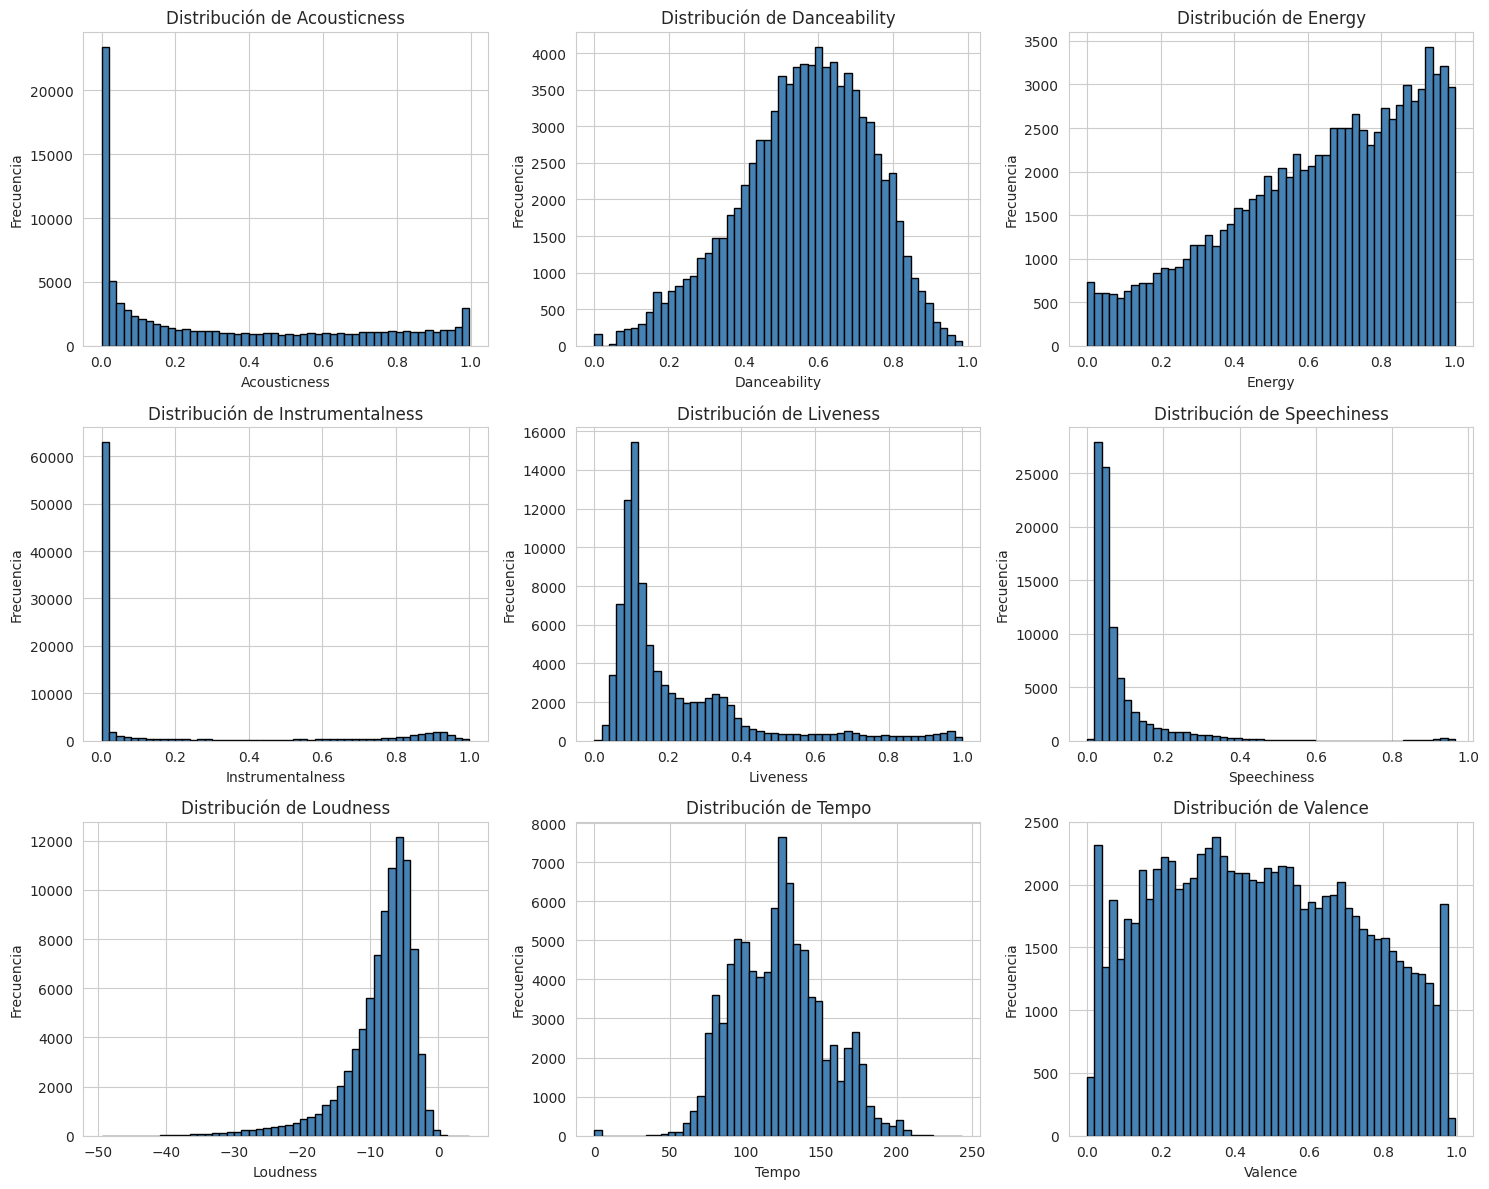

In [62]:
# Gráficos de distribución de características de audio
audio_features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 
                   'liveness', 'speechiness', 'loudness', 'tempo', 'valence']

available_features = [col for col in audio_features if col in df.columns]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, feature in enumerate(available_features[:9]):
    axes[idx].hist(df[feature].dropna(), bins=50, color='steelblue', edgecolor='black')
    axes[idx].set_title(f'Distribución de {feature.title()}')
    axes[idx].set_xlabel(feature.title())
    axes[idx].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Interpretación

- **Acousticness** muestra una distribución bimodal: muchas pistas con valores muy bajos (producciones electrónicas) y otro grupo con valores altos (acústicas).
- **Danceability** y **energy** se concentran en valores medios-altos, lo que refleja que las pistas de Spotify tienden a ser enérgicas y bailables.
- **Instrumentalness**, **liveness** y **speechiness** presentan distribuciones muy sesgadas a la derecha: la gran mayoría de las pistas tienen valores bajos, con una cola larga hacia valores altos.
- **Loudness** presenta sesgo negativo, con la mayoría de pistas entre -10 dB y -5 dB.
- **Tempo** sigue una distribución aproximadamente normal centrada en ~120 BPM.
- **Valence** se distribuye de forma aproximadamente uniforme, indicando una variedad equilibrada entre pistas "tristes" y "alegres".

## 2.2. Análisis de popularidad

Examinemos cómo se distribuye la popularidad de las pistas en el dataset.

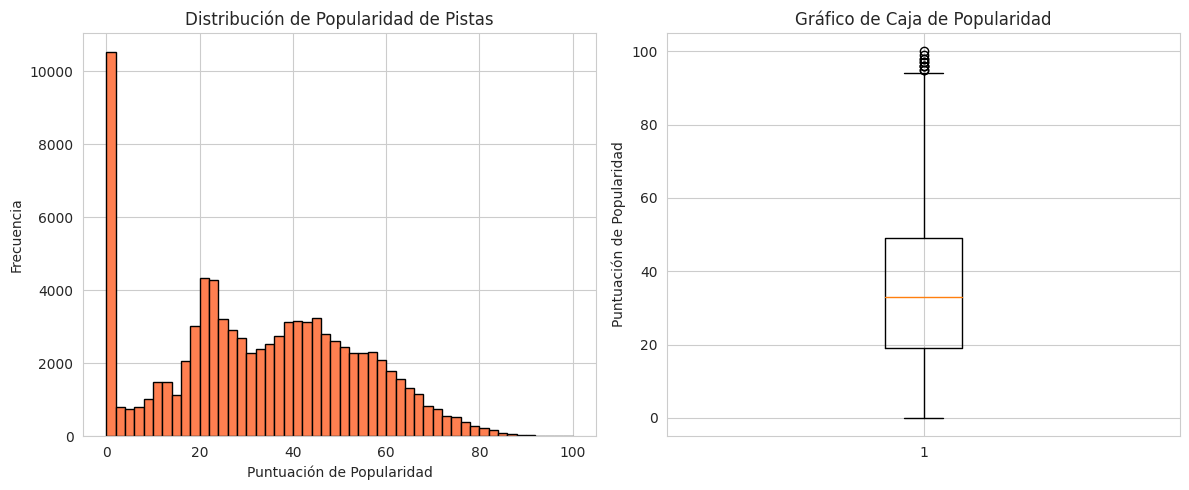


Estadísticas de Popularidad:
count    89740.000000
mean        33.198808
std         20.580640
min          0.000000
25%         19.000000
50%         33.000000
75%         49.000000
max        100.000000
Name: popularity, dtype: float64


In [63]:
if 'popularity' in df.columns:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(df['popularity'].dropna(), bins=50, color='coral', edgecolor='black')
    plt.title('Distribución de Popularidad de Pistas')
    plt.xlabel('Puntuación de Popularidad')
    plt.ylabel('Frecuencia')
    
    plt.subplot(1, 2, 2)
    plt.boxplot(df['popularity'].dropna())
    plt.title('Gráfico de Caja de Popularidad')
    plt.ylabel('Puntuación de Popularidad')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nEstadísticas de Popularidad:")
    print(df['popularity'].describe())

### Interpretación

- La distribución de popularidad es aproximadamente simétrica, con media (~33) y mediana (33) muy cercanas.
- Un 10.5% de las pistas tienen popularidad 0, lo que sugiere pistas sin apenas reproducciones o muy recientes.
- Solo un ~3% de las pistas superan una popularidad de 70, lo que confirma que los "hits" son una minoría.
- El boxplot muestra una dispersión moderada sin outliers extremos evidentes.
- La gran concentración de pistas en el rango 15–50 indica que la mayoría de canciones tienen una popularidad baja-moderada.

## 2.3. Análisis de popularidad por género

Examinamos cómo varía la popularidad media entre los distintos géneros musicales del dataset. Esto permite identificar qué géneros tienden a generar canciones más populares en Spotify.

### Top géneros

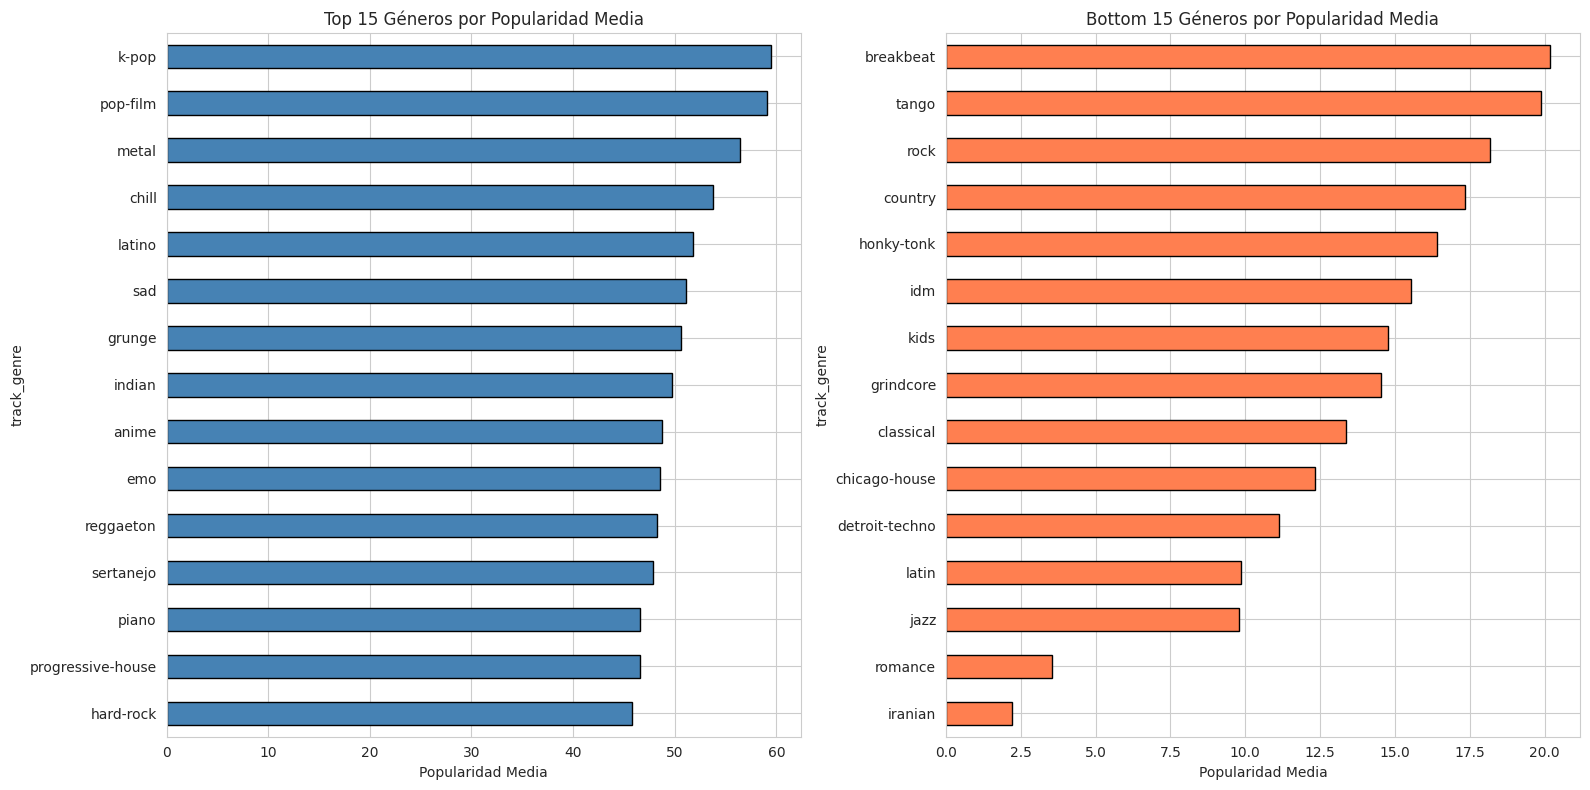

In [64]:
# Popularidad media por género
genre_popularity = df.groupby('track_genre')['popularity'].agg(['mean', 'median', 'count'])
genre_popularity.columns = ['media', 'mediana', 'cantidad']
genre_popularity = genre_popularity.sort_values('media', ascending=False)

# Top 15 géneros más populares
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 15
genre_popularity['media'].head(15).plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Top 15 Géneros por Popularidad Media')
axes[0].set_xlabel('Popularidad Media')
axes[0].invert_yaxis()

# Bottom 15
genre_popularity['media'].tail(15).plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='black'
)
axes[1].set_title('Bottom 15 Géneros por Popularidad Media')
axes[1].set_xlabel('Popularidad Media')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Interpretación

- Los géneros más populares (k-pop, pop-film, metal) alcanzan medias de popularidad en torno a 55–60, muy por encima de la media global (~33).
- Los géneros menos populares (iranian, romance, jazz, latin) presentan medias inferiores a 10, lo que indica nichos con menor audiencia en la plataforma.
- La diferencia entre el género más popular y el menos popular supera los 55 puntos, evidenciando una enorme variabilidad entre géneros.

### Distribución por género

/tmp/ipykernel_366147/442177367.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='track_genre', y='popularity', order=order, palette='viridis')


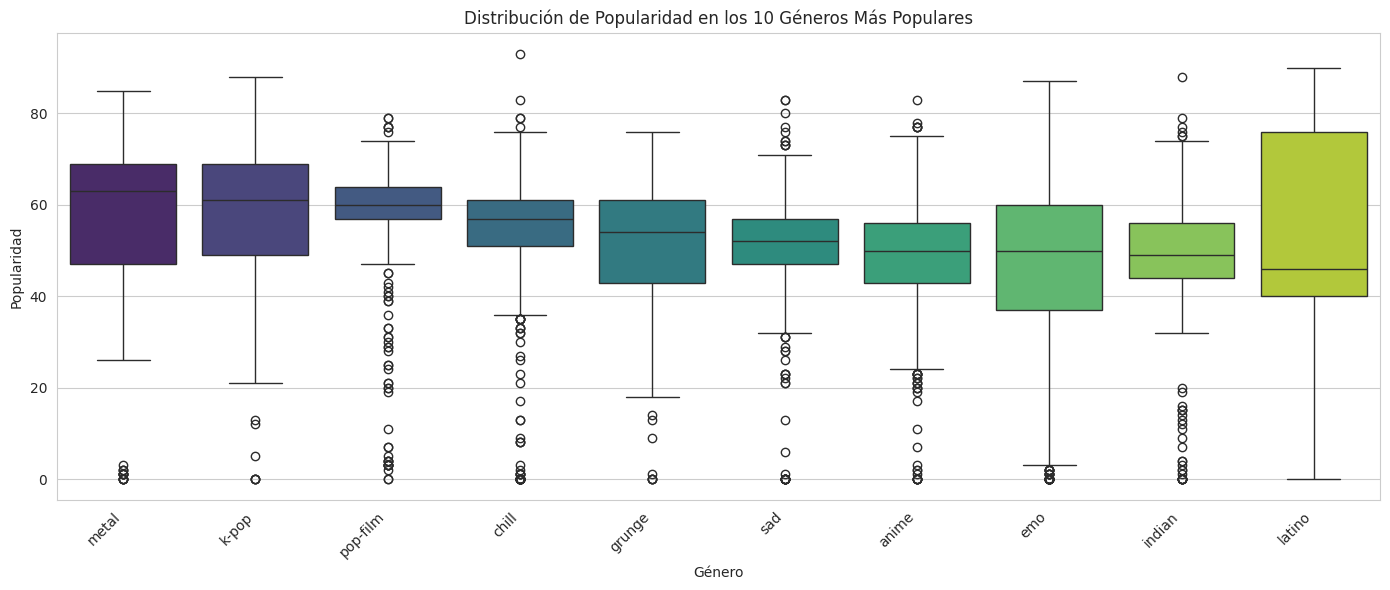

In [65]:
# Boxplot de popularidad para los 10 géneros más populares
top_genres = genre_popularity.head(10).index.tolist()

plt.figure(figsize=(14, 6))
df_top = df[df['track_genre'].isin(top_genres)]
order = df_top.groupby('track_genre')['popularity'].median().sort_values(ascending=False).index

sns.boxplot(data=df_top, x='track_genre', y='popularity', order=order, palette='viridis')
plt.title('Distribución de Popularidad en los 10 Géneros Más Populares')
plt.xlabel('Género')
plt.ylabel('Popularidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretación

- Incluso dentro de los géneros más populares, existe una gran dispersión en la popularidad de las pistas individuales: el género establece un rango base, pero no garantiza el éxito.
- Las medianas varían considerablemente entre géneros del top 10, lo que refuerza que la popularidad depende tanto del género como de las características individuales de cada canción.

### Características de audio por género

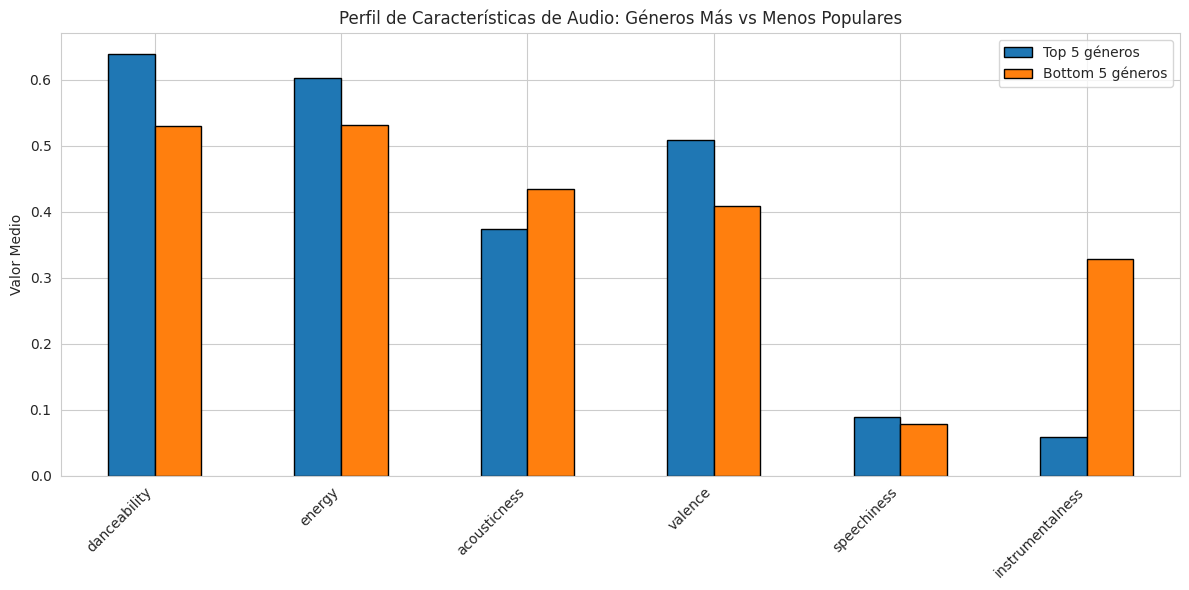

                  Top 5 géneros  Bottom 5 géneros
danceability              0.639             0.529
energy                    0.603             0.532
acousticness              0.373             0.434
valence                   0.509             0.408
speechiness               0.089             0.078
instrumentalness          0.059             0.328


In [66]:
# Perfil de características de audio de los 5 géneros más y menos populares
top_5 = genre_popularity.head(5).index.tolist()
bottom_5 = genre_popularity.tail(5).index.tolist()

audio_features_comparision = ['danceability', 'energy', 'acousticness', 'valence', 'speechiness', 'instrumentalness']

profile_top = df[df['track_genre'].isin(top_5)][audio_features_comparision].mean()
profile_bottom = df[df['track_genre'].isin(bottom_5)][audio_features_comparision].mean()

comparison = pd.DataFrame({
    'Top 5 géneros': profile_top,
    'Bottom 5 géneros': profile_bottom
})

comparison.plot(kind='bar', figsize=(12, 6), edgecolor='black')
plt.title('Perfil de Características de Audio: Géneros Más vs Menos Populares')
plt.ylabel('Valor Medio')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(comparison.round(3))

### Interpretación

- Existe una variabilidad significativa en la popularidad media entre géneros, lo que sugiere que el género es un factor relevante en la popularidad de una pista.
- Los géneros más populares tienden a presentar mayor danceability y energy, mientras que los menos populares muestran mayor instrumentalness y acousticness.
- La dispersión dentro de cada género (visible en los boxplots) indica que el género por sí solo no determina la popularidad, pero sí establece un rango base.

## 2.4. Detección de outliers en características de audio

Identificamos valores atípicos en las características de audio que podrían afectar el rendimiento de los modelos.

### Visualización

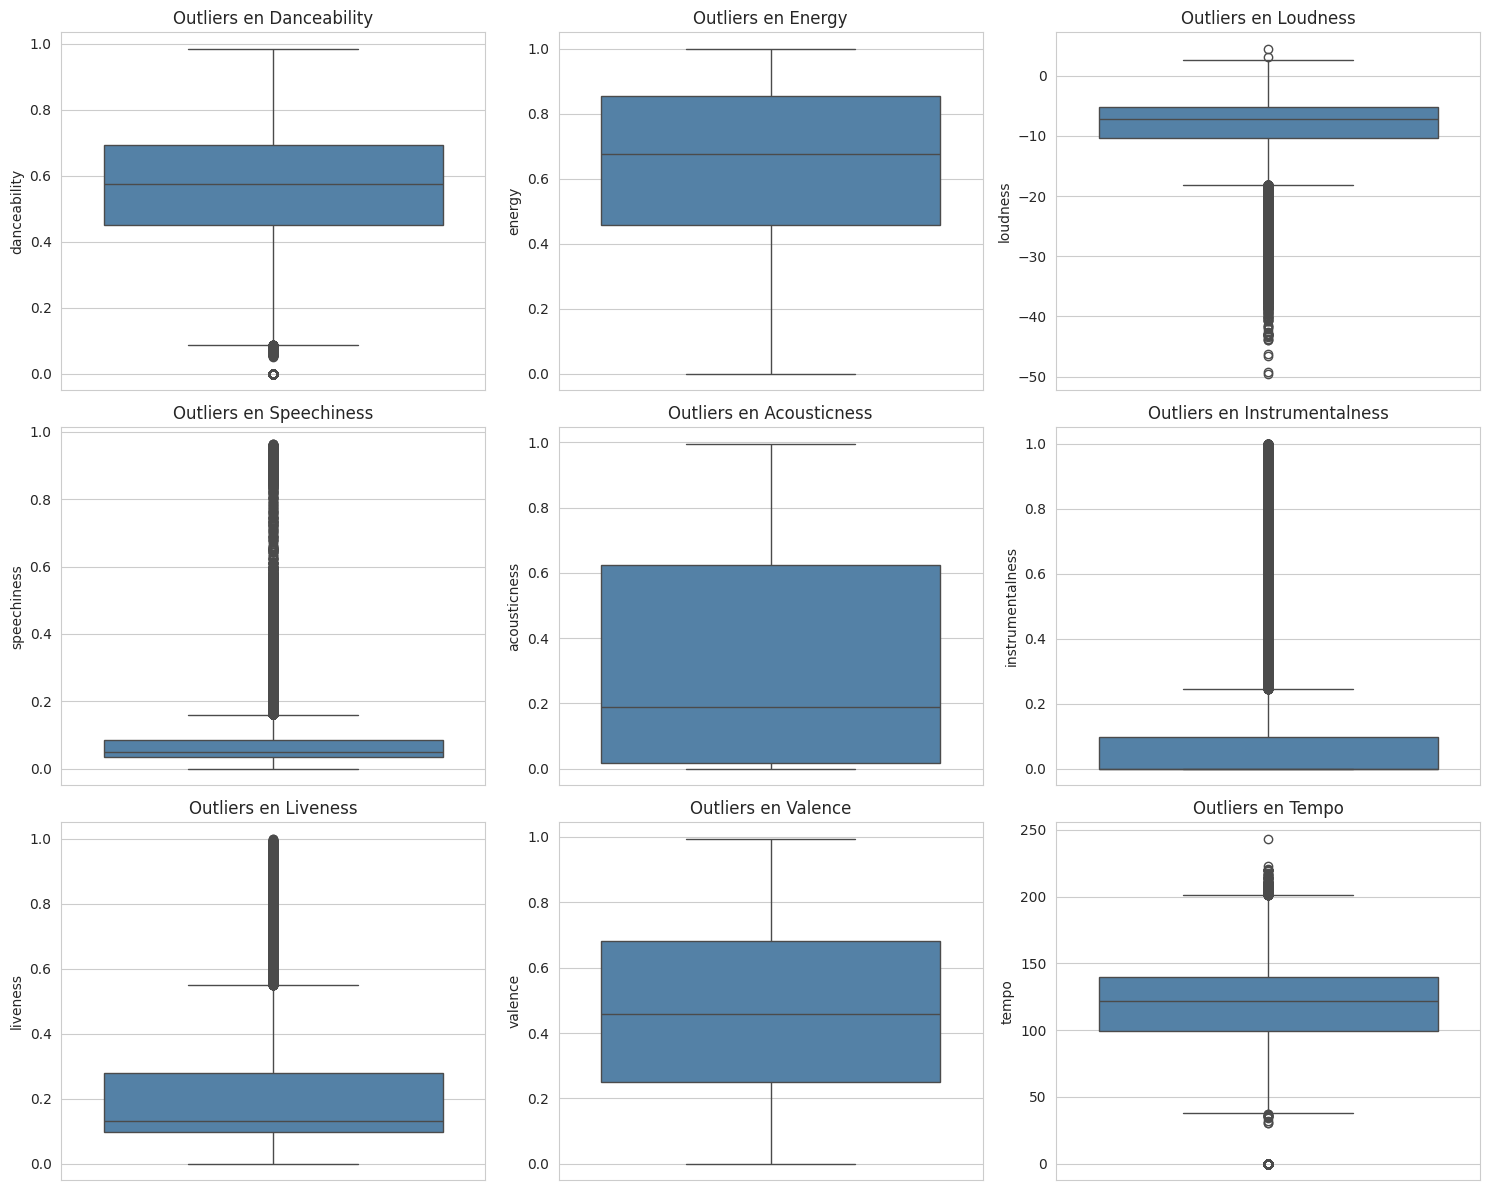

In [67]:
audio_features_full = ['danceability', 'energy', 'loudness', 'speechiness', 
                       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

available = [col for col in audio_features_full if col in df.columns]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, feature in enumerate(available[:9]):
    sns.boxplot(data=df, y=feature, ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'Outliers en {feature.title()}')

plt.tight_layout()
plt.show()

### Interpretación

- Las variables con distribución más sesgada (**speechiness**, **liveness**, **instrumentalness**) son las que producen más outliers según el método IQR, al concentrarse la mayoría de valores cerca de 0.
- **Loudness** presenta outliers en el extremo inferior (pistas excepcionalmente silenciosas, hasta -49 dB).
- **Danceability**, **energy** y **valence**, al tener distribuciones más simétricas, generan pocos outliers.

### Cuantificación

In [68]:
# Contar outliers usando método IQR
outlier_summary = []

for feature in available:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[feature] < lower) | (df[feature] > upper)).sum()
    pct = (n_outliers / len(df)) * 100
    outlier_summary.append({
        'feature': feature,
        'outliers': n_outliers,
        'porcentaje': round(pct, 2),
        'límite_inferior': round(lower, 3),
        'límite_superior': round(upper, 3)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('porcentaje', ascending=False)
print(outlier_df.to_string(index=False))

         feature  outliers  porcentaje  límite_inferior  límite_superior
instrumentalness     19613       21.86           -0.146            0.244
     speechiness     10644       11.86           -0.039            0.161
        liveness      6981        7.78           -0.173            0.550
        loudness      5026        5.60          -18.144            2.713
           tempo       514        0.57           38.041          201.298
    danceability       474        0.53            0.087            1.055
          energy         0        0.00           -0.137            1.447
    acousticness         0        0.00           -0.895            1.537
         valence         0        0.00           -0.401            1.332


### Interpretación

- Variables como `instrumentalness`, `speechiness` y `liveness` presentan distribuciones muy sesgadas, lo que genera un alto número de outliers según el método IQR.
- Estos outliers no son necesariamente errores; representan canciones con características extremas (por ejemplo, pistas puramente instrumentales o spoken word).
- Para los modelos basados en árboles (Random Forest, XGBoost) no es necesario eliminarlos. Para modelos lineales o basados en distancias, se recomienda considerar transformaciones logarítmicas o winsorización.

## 2.5 Correlación entre variables

### Objetivo

Analizar la relación entre las variables numéricas del dataset para identificar posibles dependencias y su relación con la popularidad.

Se utiliza una matriz de correlación para visualizar estas relaciones.

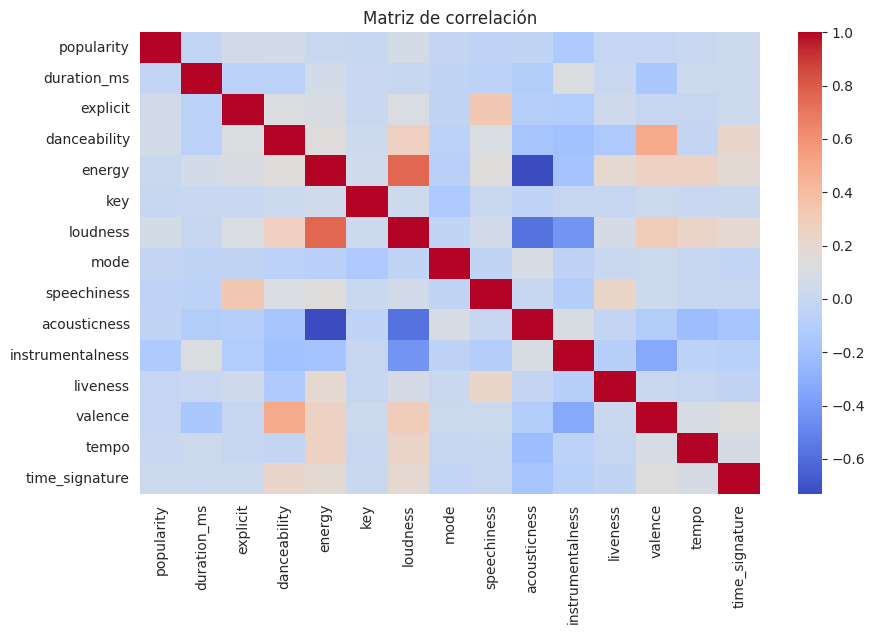

In [69]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

### Observaciones

- No se observan correlaciones muy fuertes entre la mayoría de variables  
- Algunas variables como `energy`, `loudness` o `danceability` muestran cierta relación con la popularidad  
- La popularidad no depende de una única variable, sino de una combinación de factores  

Esto refuerza la necesidad de utilizar modelos de machine learning para capturar relaciones más complejas.

## 2.6. Relación entre características de audio y popularidad

Analizamos cómo características de audio individuales se relacionan con la popularidad de las pistas.

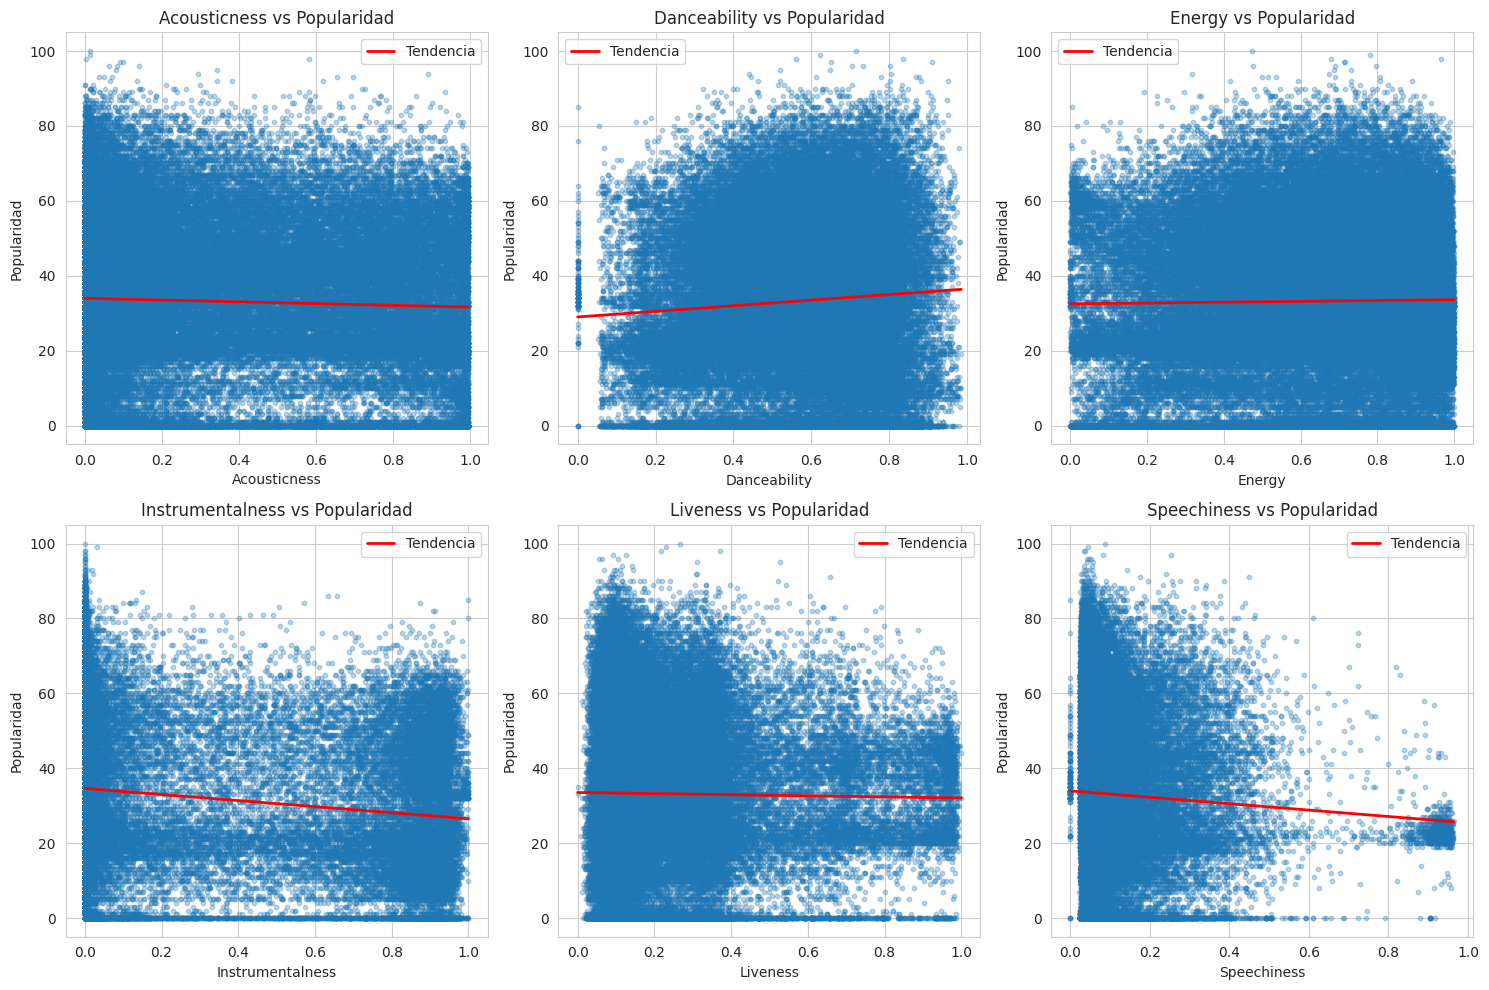

In [70]:
if 'popularity' in df.columns and len(available_features) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    features_to_plot = available_features[:6]
    
    for idx, feature in enumerate(features_to_plot):
        axes[idx].scatter(df[feature], df['popularity'], alpha=0.3, s=10)
        axes[idx].set_xlabel(feature.title())
        axes[idx].set_ylabel('Popularidad')
        axes[idx].set_title(f'{feature.title()} vs Popularidad')
        
        # Agregar línea de tendencia
        mask = df[feature].notna() & df['popularity'].notna()
        z = np.polyfit(df.loc[mask, feature], df.loc[mask, 'popularity'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
        axes[idx].plot(x_line, p(x_line), 'r-', linewidth=2, label='Tendencia')
        axes[idx].legend()
    
    plt.tight_layout()
    plt.show()

### Interpretación

- No se observan relaciones lineales fuertes entre las características de audio individuales y la popularidad; los scatter plots muestran nubes de puntos dispersas.
- La correlación más destacada es la de **instrumentalness** con la popularidad (r ≈ −0.13): las pistas más instrumentales tienden a ser menos populares.
- **Loudness** (r ≈ 0.07) y **danceability** (r ≈ 0.06) muestran correlaciones positivas leves.
- Estas correlaciones débiles confirman que la popularidad no depende de una sola variable, lo que justifica el uso de modelos multivariantes en las fases siguientes.

---

# 3. Preparación de datos

## 3.1. Selección y transformación de variables

En esta fase se seleccionan y transforman las variables para su uso en modelos de machine learning.

Se eliminan variables que no aportan valor predictivo o que no pueden ser utilizadas directamente por los modelos, como identificadores o variables de texto libre.

Además, se construye un dataset específico para modelado (`df_model`), manteniendo el dataset original para el análisis exploratorio.

In [71]:
df_model = df.copy()

cols_to_drop = ["track_name", "artists", "album_name", "track_id", "track_genre"]

df_model = df_model.drop(columns=[col for col in cols_to_drop if col in df_model.columns])

## 3.2 Separación de variables

En esta fase se separa la variable objetivo (`popularity`) del resto de variables predictoras.

In [72]:
X = df_model.drop(columns=["popularity"])
y = df_model["popularity"]

## 3.3. División entre train y test

Se divide el dataset en conjunto de entrenamiento y test para evaluar correctamente los modelos.

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 3.4. Escalado de variables

Algunos modelos requieren que las variables estén escaladas.

In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3.5. Preparación para clasificación

Se define una variable binaria `hit` para transformar el problema en clasificación, permitiendo identificar canciones con alta popularidad.  

Antes de definir la variable, vamos a hacer un pequeño análisis de percentiles para justificar el umbral.

In [75]:
# Análisis de percentiles para justificar el umbral
print("Percentiles de popularidad:")
for p in [50, 70, 75, 80, 90, 95]:
    print(f"  Percentil {p}: {df_model['popularity'].quantile(p/100):.0f}")

Percentiles de popularidad:
  Percentil 50: 33
  Percentil 70: 45
  Percentil 75: 49
  Percentil 80: 52
  Percentil 90: 60
  Percentil 95: 67


### Justificación del umbral

Los percentiles muestran que la distribución de popularidad tiene la siguiente estructura:

| Percentil | Popularidad |
|-----------|-------------|
| 50 | 33 |
| 70 | 45 |
| **75** | **49** |
| 80 | 52 |
| 90 | 60 |
| 95 | 67 |

Se define el umbral de **popularidad > 49** (percentil 75) para clasificar una canción como "hit". Este valor divide el dataset en un **75% no-hit / 25% hit**, un ratio que:

- Es lo suficientemente selectivo para que "hit" represente las canciones que destacan por encima de la mayoría.
- Genera un desbalanceo moderado (3:1), manejable por los algoritmos de clasificación sin necesidad obligatoria de técnicas de resampling.
- Evita el desbalanceo extremo de umbrales más altos (ej. popularidad > 70 dejaría solo un 3% de hits, haciendo imposible la detección para la mayoría de modelos).

In [76]:
df_model["hit"] = (df_model["popularity"] > 49).astype(int)
print(f"Distribución de la variable 'hit' (umbral > 49):")
print(df_model["hit"].value_counts())
print(f"\nProporción: {df_model['hit'].value_counts(normalize=True).round(3).to_dict()}")

Distribución de la variable 'hit' (umbral > 49):
hit
0    68531
1    21209
Name: count, dtype: int64

Proporción: {0: 0.764, 1: 0.236}


In [77]:
X_class = df_model.drop(columns=["popularity", "hit"])
y_class = df_model["hit"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

print(f"Variables de clasificación: {X_class.columns.tolist()}")
print(f"Distribución de clases:\n{y_class.value_counts(normalize=True).round(3)}")

Variables de clasificación: ['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
Distribución de clases:
hit
0    0.764
1    0.236
Name: proportion, dtype: float64


### Interpretación del desbalanceo

La distribución de clases muestra un **desbalanceo moderado**: aproximadamente el 75% de las pistas son "No Hit" y el 25% son "Hit" (ratio 3:1).

Este nivel de desbalanceo es habitual en problemas reales de clasificación y los modelos estándar deberían poder manejarlo razonablemente:
- Un clasificador que prediga siempre "No Hit" obtendría un **accuracy del 75%**, por lo que ya no es una métrica tan engañosa como lo sería con un 97%.
- Aun así, **F1-Score** sigue siendo la métrica clave para evaluar la capacidad de detección de hits.
- La proporción 3:1 permite a los modelos ver suficientes ejemplos de la clase "Hit" durante el entrenamiento.

---

# 4. Modelos de regresión

### Objetivo

Construir modelos de machine learning capaces de predecir la puntuación de popularidad (0–100) de una canción a partir de sus características de audio.

Se compararán modelos de complejidad creciente: desde una regresión lineal simple hasta modelos ensemble basados en árboles.

## 4.1. Modelo base: Regresión lineal

Se utiliza la regresión lineal ordinaria como modelo baseline. Al ser el modelo más simple, permite establecer un punto de referencia para comparar con modelos más complejos.

In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Regresión Lineal ===")
print(f"RMSE : {rmse_lr:.3f}")
print(f"MAE  : {mae_lr:.3f}")
print(f"R²   : {r2_lr:.4f}")

=== Regresión Lineal ===
RMSE : 20.128
MAE  : 16.584
R²   : 0.0313


### Interpretación

El modelo de regresión lineal obtiene un **R² = 0.031**, lo que significa que solo explica el **3.1% de la varianza** de la popularidad. Es un resultado muy pobre.

- Un **RMSE de 20.1** en una escala de 0–100 implica que las predicciones se desvían, en promedio, ±20 puntos de la popularidad real — un margen demasiado amplio para ser útil.
- Esto confirma lo observado en el EDA: las correlaciones lineales individuales entre las características de audio y la popularidad son muy débiles (la más fuerte es instrumentalness con r ≈ −0.13).
- El modelo lineal asume relaciones lineales y aditivas, lo cual es una simplificación excesiva para este problema.

**Conclusión**: la regresión lineal no es adecuada, pero cumple su función como **baseline** contra el cual comparar modelos más complejos.

## 4.2. Regularización: Ridge y Lasso

Se aplican modelos de regresión regularizada para evaluar si la penalización de coeficientes mejora la generalización.

- **Ridge (L2)**: penaliza la magnitud de los coeficientes, reduce el sobreajuste.
- **Lasso (L1)**: además de regularizar, puede eliminar variables irrelevantes (coeficientes = 0).

In [79]:
from sklearn.linear_model import Ridge, Lasso

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("=== Ridge (α=1.0) ===")
print(f"RMSE : {rmse_ridge:.3f}")
print(f"MAE  : {mae_ridge:.3f}")
print(f"R²   : {r2_ridge:.4f}")
print()
print("=== Lasso (α=0.1) ===")
print(f"RMSE : {rmse_lasso:.3f}")
print(f"MAE  : {mae_lasso:.3f}")
print(f"R²   : {r2_lasso:.4f}")
print()

# Coeficientes Lasso (variables eliminadas)
lasso_coefs = pd.Series(lasso.coef_, index=X.columns)
print("Coeficientes Lasso:")
print(lasso_coefs.round(4).to_string())

=== Ridge (α=1.0) ===
RMSE : 20.128
MAE  : 16.584
R²   : 0.0313

=== Lasso (α=0.1) ===
RMSE : 20.128
MAE  : 16.613
R²   : 0.0313

Coeficientes Lasso:
duration_ms        -0.3056
explicit            1.0225
danceability        1.5301
energy             -0.0000
key                -0.0000
loudness            0.0878
mode               -0.2250
speechiness        -1.6382
acousticness       -0.1966
instrumentalness   -2.7940
liveness            0.0000
valence            -1.9449
tempo               0.0475
time_signature      0.2844


### Interpretación

Tanto Ridge como Lasso obtienen resultados **prácticamente idénticos** a la regresión lineal (R² ≈ 0.031, RMSE ≈ 20.1).

¿Por qué la regularización no mejora?
- La regularización combate el **sobreajuste** (overfitting), pero aquí el problema es el contrario: **infraajuste** (underfitting). El modelo lineal no tiene suficiente capacidad expresiva para capturar las relaciones entre audio y popularidad.
- Con solo ~14 variables numéricas, no hay muchos coeficientes que regularizar, y las relaciones son débiles de por sí.

**Lasso** no elimina ninguna variable (todos los coeficientes son distintos de cero), lo que indica que todas las características aportan algo de información, aunque sea marginal.

**Conclusión**: la regularización no soluciona el problema fundamental. Necesitamos modelos capaces de capturar **relaciones no lineales**.

## 4.3. Modelos basados en árboles

Se entrenan modelos no lineales capaces de capturar interacciones complejas entre variables.

- **Random Forest**: ensemble de árboles de decisión entrenados con bagging.
- **Gradient Boosting**: ensemble secuencial que corrige errores del modelo anterior.

Estos modelos no requieren escalado, por lo que se entrenan con los datos originales.

In [80]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Random Forest
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Gradient Boosting
gb_reg = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
gb_reg.fit(X_train, y_train)
y_pred_gb = gb_reg.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("=== Random Forest Regressor ===")
print(f"RMSE : {rmse_rf:.3f}")
print(f"MAE  : {mae_rf:.3f}")
print(f"R²   : {r2_rf:.4f}")
print()
print("=== Gradient Boosting Regressor ===")
print(f"RMSE : {rmse_gb:.3f}")
print(f"MAE  : {mae_gb:.3f}")
print(f"R²   : {r2_gb:.4f}")

=== Random Forest Regressor ===
RMSE : 18.334
MAE  : 14.589
R²   : 0.1963

=== Gradient Boosting Regressor ===
RMSE : 18.911
MAE  : 15.158
R²   : 0.1449


### Interpretación

Los modelos basados en árboles marcan una **mejora sustancial** frente a los lineales:

| Modelo | R² | Mejora vs baseline |
|--------|-----|-------------------|
| Regresión Lineal | 0.031 | — |
| Random Forest | **0.196** | ×6.3 |
| Gradient Boosting | 0.145 | ×4.6 |

- **Random Forest** es el mejor modelo con R² = 0.196 y RMSE = 18.33 — una reducción del 9% en el error respecto a la regresión lineal.
- **Gradient Boosting** queda ligeramente por detrás (R² = 0.145), posiblemente porque sus hiperparámetros por defecto no son óptimos para este dataset (se podría mejorar con tuning).

Sin embargo, un R² = 0.20 sigue significando que el **80% de la varianza** de la popularidad no se explica por las características de audio. Esto no es un fallo de los modelos, sino una **limitación inherente de los datos**: la popularidad depende en gran medida de factores externos al audio (marketing, influencia del artista, presencia en playlists, tendencias sociales).

**Conclusión**: los modelos de árboles capturan patrones no lineales reales, pero el techo predictivo con solo datos de audio es bajo.

## 4.4. Comparación de modelos de regresión

Se comparan los cuatro modelos entrenados utilizando RMSE, MAE y R².

           Modelo      RMSE       MAE       R²
    Random Forest 18.333640 14.588822 0.196332
Gradient Boosting 18.911014 15.157644 0.144916
            Ridge 20.127827 16.583742 0.031337
 Regresión Lineal 20.127827 16.583735 0.031337
            Lasso 20.128473 16.613389 0.031274


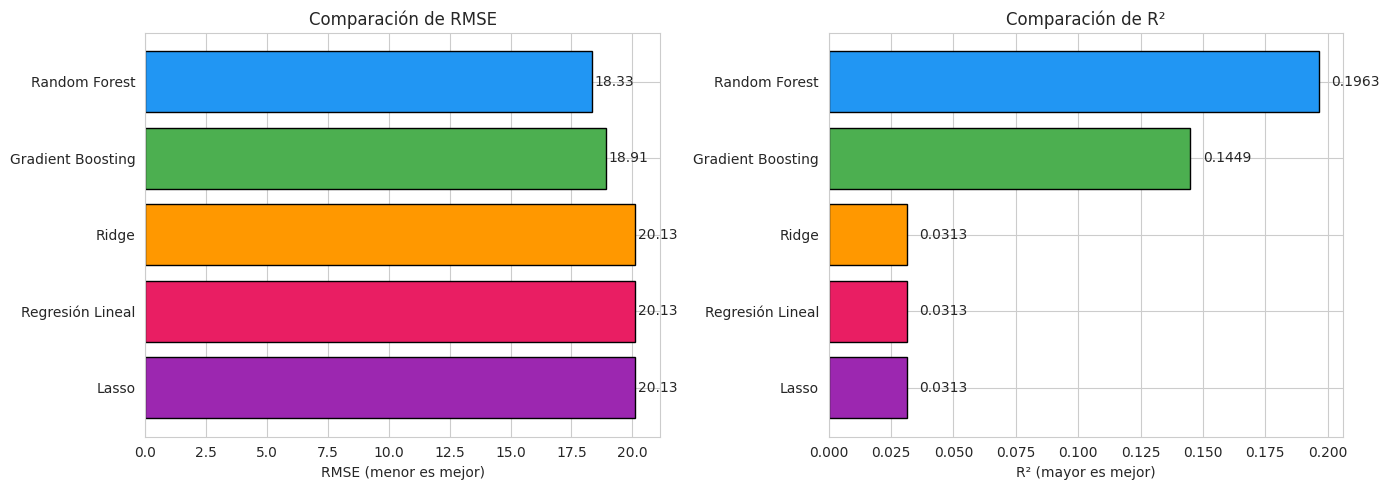

In [81]:
reg_results = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Ridge', 'Lasso', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [rmse_lr, rmse_ridge, rmse_lasso, rmse_rf, rmse_gb],
    'MAE': [mae_lr, mae_ridge, mae_lasso, mae_rf, mae_gb],
    'R²': [r2_lr, r2_ridge, r2_lasso, r2_rf, r2_gb]
}).sort_values('RMSE')

print(reg_results.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

# RMSE
bars1 = axes[0].barh(reg_results['Modelo'], reg_results['RMSE'], color=colors, edgecolor='black')
axes[0].set_xlabel('RMSE (menor es mejor)')
axes[0].set_title('Comparación de RMSE')
axes[0].invert_yaxis()
for bar, val in zip(bars1, reg_results['RMSE']):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center')

# R²
bars2 = axes[1].barh(reg_results['Modelo'], reg_results['R²'], color=colors, edgecolor='black')
axes[1].set_xlabel('R² (mayor es mejor)')
axes[1].set_title('Comparación de R²')
axes[1].invert_yaxis()
for bar, val in zip(bars2, reg_results['R²']):
    axes[1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')

plt.tight_layout()
plt.show()

### Interpretación de la comparación

El gráfico muestra una separación clara en **dos grupos**:

1. **Modelos lineales** (Regresión Lineal, Ridge, Lasso): rendimiento prácticamente idéntico entre sí, con R² ≈ 0.03. La regularización no aporta mejora porque el problema no es el sobreajuste sino la incapacidad del modelo lineal para capturar la complejidad del problema.

2. **Modelos ensemble** (Random Forest, Gradient Boosting): mejora significativa, con Random Forest liderando (R² = 0.20).

La brecha entre ambos grupos demuestra que existen **relaciones no lineales** entre las características de audio y la popularidad que solo los modelos basados en árboles pueden capturar (interacciones entre variables, umbrales, combinaciones).

## 4.5. Predicciones vs valores reales (mejor modelo)

Visualizamos las predicciones del mejor modelo de regresión frente a los valores reales.

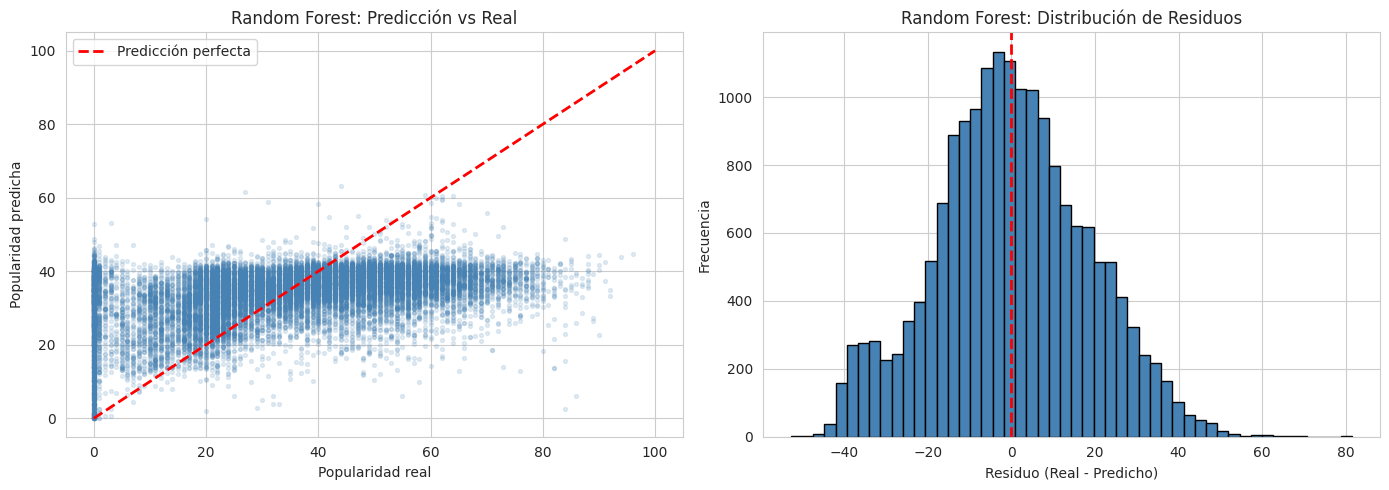

Residuo medio: -0.023
Desviación estándar de residuos: 18.334


In [82]:
# Seleccionar el mejor modelo de regresión por RMSE
best_reg_name = reg_results.iloc[0]['Modelo']
best_reg_preds = {'Regresión Lineal': y_pred_lr, 'Ridge': y_pred_ridge, 'Lasso': y_pred_lasso,
                  'Random Forest': y_pred_rf, 'Gradient Boosting': y_pred_gb}
y_pred_best = best_reg_preds[best_reg_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter de predicción vs real
axes[0].scatter(y_test, y_pred_best, alpha=0.15, s=8, color='steelblue')
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('Popularidad real')
axes[0].set_ylabel('Popularidad predicha')
axes[0].set_title(f'{best_reg_name}: Predicción vs Real')
axes[0].legend()

# Distribución de residuos
residuos = y_test - y_pred_best
axes[1].hist(residuos, bins=50, color='steelblue', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuo (Real - Predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'{best_reg_name}: Distribución de Residuos')

plt.tight_layout()
plt.show()

print(f"Residuo medio: {residuos.mean():.3f}")
print(f"Desviación estándar de residuos: {residuos.std():.3f}")

### Interpretación de los residuos

- El **residuo medio ≈ 0** confirma que el modelo no tiene sesgo sistemático: no sobreestima ni subestima la popularidad de forma consistente.
- La **desviación estándar de 18.3** indica una dispersión alta de los errores: para una canción con popularidad real de 50, el modelo podría predecir entre 32 y 68 con un intervalo de ±1σ.
- El scatter de predicción vs real muestra una nube difusa lejos de la diagonal perfecta, especialmente para popularidades extremas (muy bajas o muy altas).
- La distribución de residuos es aproximadamente simétrica y centrada en cero, lo que es correcto — pero su amplitud confirma que las características de audio por sí solas no son suficientes para predecir con precisión la popularidad.

---

# 5. Modelos de clasificación

### Objetivo

Clasificar las canciones como **hit** (popularidad > 70) o **no hit** utilizando las características de audio.

Este enfoque convierte el problema en una tarea de clasificación binaria, útil para escenarios donde interesa detectar canciones con alto potencial de éxito.

## 5.1. Modelo base: Regresión logística

Modelo lineal baseline para clasificación binaria.

In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Escalar datos de clasificación
Xc_train_scaled = scaler.fit_transform(Xc_train)
Xc_test_scaled = scaler.transform(Xc_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(Xc_train_scaled, yc_train)
yc_pred_log = log_reg.predict(Xc_test_scaled)

print("=== Regresión Logística ===")
print(classification_report(yc_test, yc_pred_log, target_names=['No Hit', 'Hit']))

=== Regresión Logística ===
              precision    recall  f1-score   support

      No Hit       0.77      1.00      0.87     13789
         Hit       0.43      0.01      0.02      4159

    accuracy                           0.77     17948
   macro avg       0.60      0.50      0.44     17948
weighted avg       0.69      0.77      0.67     17948



### Interpretación

La regresión logística obtiene un **accuracy del 77%**, pero esta cifra engaña:

- **Recall para "Hit" = 0.01**: de 4.159 hits reales en test, el modelo apenas detecta unos pocos. Predice "No Hit" en el 99% de los casos.
- **Precision para "Hit" = 0.43**: cuando se atreve a predecir "Hit", acierta un 43% de las veces, pero lo hace con tan poco recall que es irrelevante.

¿Por qué? La regresión logística busca un hiperplano lineal de separación. En un espacio donde las características de audio no separan claramente las clases, el modelo opta por la estrategia conservadora de predecir la clase mayoritaria.

**Conclusión**: como baseline, la regresión logística confirma que una frontera de decisión lineal es insuficiente para este problema.

## 5.2. Modelos basados en árboles

### Random Forest Classifier

In [84]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

rf_clf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_clf.fit(Xc_train, yc_train)
yc_pred_rf = rf_clf.predict(Xc_test)

print("=== Random Forest Classifier ===")
print(classification_report(yc_test, yc_pred_rf, target_names=['No Hit', 'Hit']))

=== Random Forest Classifier ===
              precision    recall  f1-score   support

      No Hit       0.77      1.00      0.87     13789
         Hit       0.65      0.03      0.05      4159

    accuracy                           0.77     17948
   macro avg       0.71      0.51      0.46     17948
weighted avg       0.74      0.77      0.68     17948



### Interpretación

Random Forest mejora la **precision para "Hit" a 0.65** — la más alta de todos los modelos — pero su **recall sigue siendo muy bajo (0.03)**.

Esto significa que el modelo es muy selectivo: cuando predice "Hit", acierta en un 65% de los casos, pero solo identifica un 3% de los hits reales. Es un modelo **conservador** que prefiere no arriesgarse a falsos positivos.

La naturaleza de bagging (promediar muchos árboles) tiende a suavizar las predicciones hacia la clase mayoritaria, lo que explica este comportamiento.

### Gradient Boosting Classifier

In [85]:
gb_clf = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
gb_clf.fit(Xc_train, yc_train)
yc_pred_gb = gb_clf.predict(Xc_test)

print("=== Gradient Boosting Classifier ===")
print(classification_report(yc_test, yc_pred_gb, target_names=['No Hit', 'Hit']))

=== Gradient Boosting Classifier ===
              precision    recall  f1-score   support

      No Hit       0.78      0.99      0.87     13789
         Hit       0.56      0.05      0.09      4159

    accuracy                           0.77     17948
   macro avg       0.67      0.52      0.48     17948
weighted avg       0.72      0.77      0.69     17948



### Interpretación

Gradient Boosting logra un equilibrio ligeramente mejor: **precision = 0.56** y **recall = 0.05**, con F1 = 0.09.

Su naturaleza secuencial (cada árbol corrige errores del anterior) le da algo más de sensibilidad a la clase minoritaria que Random Forest. Aun así, el recall sigue siendo bajo — el modelo detecta solo 1 de cada 20 hits reales.

La mejora respecto a la regresión logística es clara: el boosting captura patrones no lineales que el modelo lineal no puede.

## 5.3. Otros modelos

### K-Nearest Neighbors (KNN)

In [86]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# KNN
knn = KNeighborsClassifier(n_neighbors=7, n_jobs=-1)
knn.fit(Xc_train_scaled, yc_train)
yc_pred_knn = knn.predict(Xc_test_scaled)

print("=== K-Nearest Neighbors (k=7) ===")
print(classification_report(yc_test, yc_pred_knn, target_names=['No Hit', 'Hit']))

=== K-Nearest Neighbors (k=7) ===
              precision    recall  f1-score   support

      No Hit       0.79      0.91      0.85     13789
         Hit       0.40      0.20      0.26      4159

    accuracy                           0.75     17948
   macro avg       0.60      0.55      0.55     17948
weighted avg       0.70      0.75      0.71     17948



### Interpretación

KNN es el **modelo más interesante en clasificación**, con resultados muy distintos a los demás:

| Métrica | KNN | Mejor del resto (GB) |
|---------|-----|---------------------|
| Precision (Hit) | 0.40 | 0.56 |
| Recall (Hit) | **0.20** | 0.05 |
| F1 (Hit) | **0.26** | 0.09 |

- KNN detecta un **20% de los hits reales** (recall = 0.20), frente al 5% de Gradient Boosting y el 3% de Random Forest.
- Sacrifica precision (0.40 vs 0.56-0.65) a cambio de un recall mucho mayor.
- Su **F1 = 0.26** es ~3x superior al segundo mejor modelo.

¿Por qué KNN funciona mejor aquí? Al basarse en vecinos cercanos, KNN es sensible a **clusters locales** de hits en el espacio de características. Los hits comparten patrones de audio con otros hits cercanos, y KNN los detecta sin asumir una forma específica de frontera de decisión.

### Conclusión general de clasificación

KNN emerge como el **mejor modelo de clasificación**, no por accuracy (que es la más baja con 75%), sino por su capacidad real de detectar hits.

Ranking por F1-Score para la clase "Hit":

1. **KNN (k=7)**: F1 = 0.26 — mejor equilibrio entre detección y precisión
2. Gradient Boosting: F1 = 0.09 — algo de detección pero muy conservador
3. Random Forest: F1 = 0.05 — alta precision pero recall mínimo
4. Regresión Logística: F1 = 0.02 — prácticamente inútil para detectar hits

La lección clave es que **accuracy no es la métrica adecuada** en problemas desbalanceados: el modelo con peor accuracy (KNN, 75%) es el más útil para el objetivo real (detectar hits).

## 5.4. Comparación de modelos de clasificación

Se comparan todos los modelos utilizando Accuracy, Precision, Recall y F1-score.

             Modelo  Accuracy  Precision  Recall     F1
          KNN (k=7)    0.7459     0.4010  0.1957 0.2630
  Gradient Boosting    0.7707     0.5558  0.0515 0.0942
      Random Forest    0.7711     0.6506  0.0260 0.0499
Regresión Logística    0.7677     0.4321  0.0084 0.0165


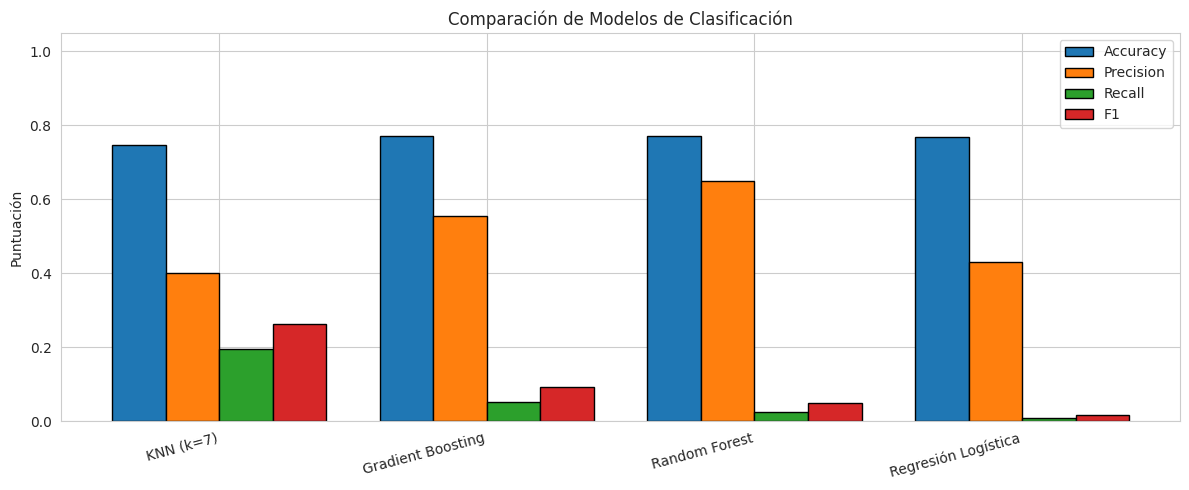

In [87]:
clf_models = {
    'Regresión Logística': yc_pred_log,
    'Random Forest': yc_pred_rf,
    'Gradient Boosting': yc_pred_gb,
    'KNN (k=7)': yc_pred_knn,
}

clf_results = []
for name, preds in clf_models.items():
    clf_results.append({
        'Modelo': name,
        'Accuracy': accuracy_score(yc_test, preds),
        'Precision': precision_score(yc_test, preds, zero_division=0),
        'Recall': recall_score(yc_test, preds, zero_division=0),
        'F1': f1_score(yc_test, preds, zero_division=0)
    })

clf_results_df = pd.DataFrame(clf_results).sort_values('F1', ascending=False)
print(clf_results_df.round(4).to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(12, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(clf_results_df))
width = 0.2

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, clf_results_df[metric], width, label=metric, edgecolor='black')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(clf_results_df['Modelo'], rotation=15, ha='right')
ax.set_ylabel('Puntuación')
ax.set_title('Comparación de Modelos de Clasificación')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

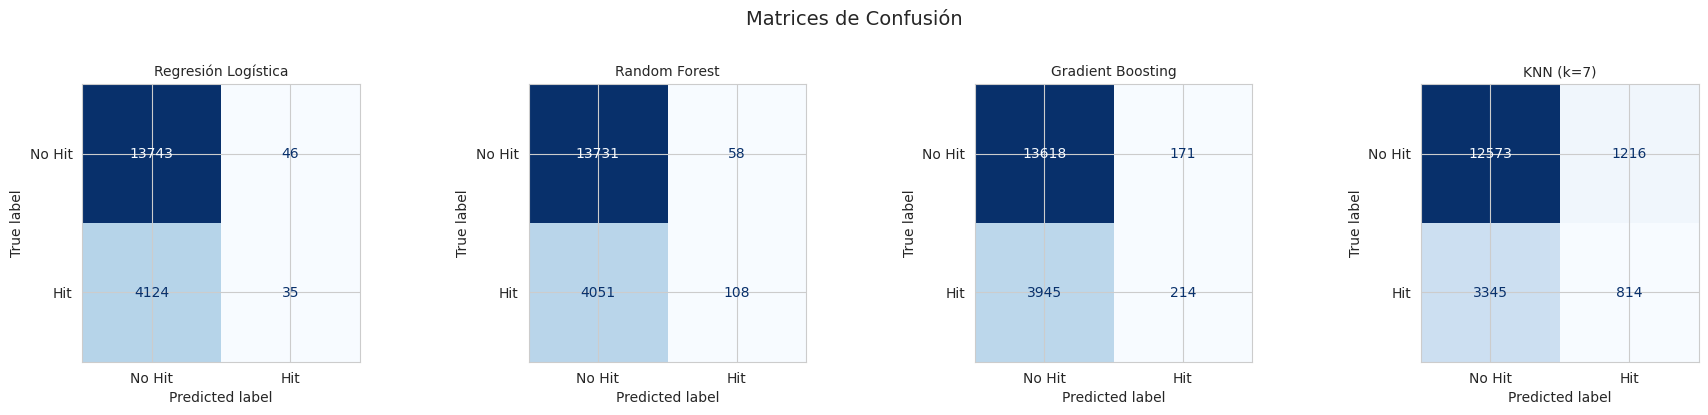

In [88]:
# Matrices de confusión de los modelos
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for idx, (name, preds) in enumerate(clf_models.items()):
    cm = confusion_matrix(yc_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['No Hit', 'Hit']).plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(name, fontsize=10)

plt.suptitle('Matrices de Confusión', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5.5. Conclusiones de clasificación

| Hallazgo | Detalle |
|----------|---------|
| KNN es el mejor clasificador | F1 = 0.26 para "Hit", detecta el 20% de los hits reales |
| Accuracy es engañosa | Todos los modelos rondan 75-77%, pero su utilidad real varía enormemente |
| Los modelos de árboles son conservadores | Alta precision pero recall muy bajo (3-5%) — prefieren no arriesgarse |
| KNN explota la estructura local | Los hits forman clusters en el espacio de características que KNN puede detectar |

**¿Por qué los resultados son moderados?** Incluso con un umbral más permisivo (P75), las características de audio por sí solas no determinan completamente si una canción será popular. Los factores externos (artista, momento de lanzamiento, presencia en playlists) siguen siendo determinantes.

**Para mejorar**: se podrían aplicar técnicas como `class_weight='balanced'`, ajuste de umbral de decisión, o SMOTE para potenciar la detección de hits.

---

# 6. Evaluación y comparación global

### Objetivo

Consolidar los resultados de regresión y clasificación en una vista unificada para seleccionar los mejores modelos.

## 6.1. Resumen de regresión

In [89]:
print("=== Resumen de modelos de regresión ===\n")
print(reg_results.round(4).to_string(index=False))
print(f"\nMejor modelo (menor RMSE): {reg_results.iloc[0]['Modelo']}")
print(f"  RMSE = {reg_results.iloc[0]['RMSE']:.3f}  |  R² = {reg_results.iloc[0]['R²']:.4f}")

=== Resumen de modelos de regresión ===

           Modelo    RMSE     MAE     R²
    Random Forest 18.3336 14.5888 0.1963
Gradient Boosting 18.9110 15.1576 0.1449
            Ridge 20.1278 16.5837 0.0313
 Regresión Lineal 20.1278 16.5837 0.0313
            Lasso 20.1285 16.6134 0.0313

Mejor modelo (menor RMSE): Random Forest
  RMSE = 18.334  |  R² = 0.1963


### Interpretación

El salto de R² = 0.03 (modelos lineales) a R² = 0.20 (Random Forest) confirma que existen patrones no lineales en los datos. Sin embargo, el techo de R² = 0.20 indica que el 80% de la variabilidad de la popularidad no se puede explicar con características de audio.

Esto no significa que los modelos sean inútiles: un RMSE de ~18 puntos permite al menos **ordenar relativa mente** las pistas por popularidad esperada, aunque no predecir su puntuación exacta.

## 6.2. Resumen de clasificación

In [90]:
print("=== Resumen de modelos de clasificación ===\n")
print(clf_results_df.round(4).to_string(index=False))
print(f"\nMejor modelo (mayor F1): {clf_results_df.iloc[0]['Modelo']}")
print(f"  F1 = {clf_results_df.iloc[0]['F1']:.4f}  |  Recall = {clf_results_df.iloc[0]['Recall']:.4f}")

=== Resumen de modelos de clasificación ===

             Modelo  Accuracy  Precision  Recall     F1
          KNN (k=7)    0.7459     0.4010  0.1957 0.2630
  Gradient Boosting    0.7707     0.5558  0.0515 0.0942
      Random Forest    0.7711     0.6506  0.0260 0.0499
Regresión Logística    0.7677     0.4321  0.0084 0.0165

Mejor modelo (mayor F1): KNN (k=7)
  F1 = 0.2630  |  Recall = 0.1957


### Interpretación

Con el umbral P75 (popularidad > 49), los modelos de clasificación muestran diferencias significativas:

- **KNN** destaca claramente con F1 = 0.26, el único modelo que logra un equilibrio razonable entre detección y precisión.
- Los modelos de árboles (RF, GB) son muy conservadores: priorizan precision sobre recall, detectando pocos hits.
- La regresión logística es prácticamente inútil como clasificador de hits.

La diferencia entre accuracy (~75% para todos) y F1 (de 0.02 a 0.26) ilustra por qué **la elección de métrica es crítica** en problemas desbalanceados.

## 6.3. Visualización comparativa global

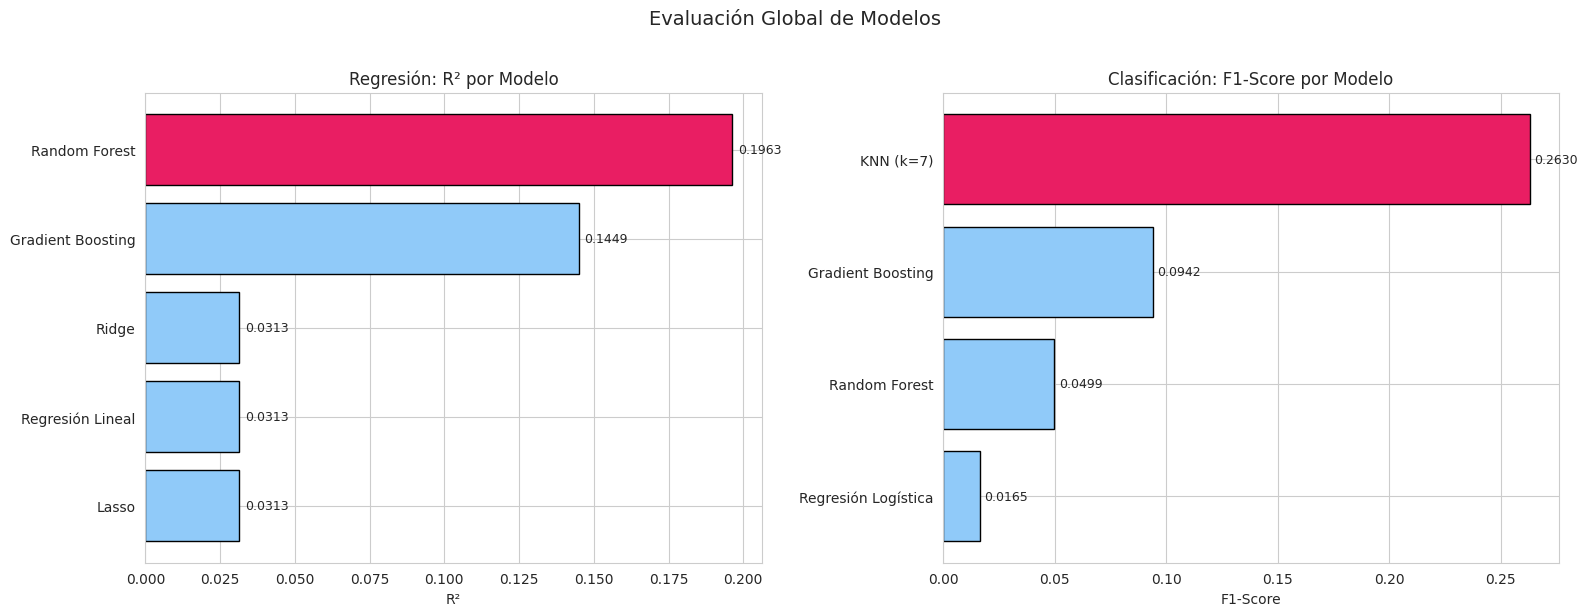

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Regresión: R² ---
reg_sorted = reg_results.sort_values('R²', ascending=True)
colors_reg = ['#E91E63' if v == reg_sorted['R²'].max() else '#90CAF9' for v in reg_sorted['R²']]
axes[0].barh(reg_sorted['Modelo'], reg_sorted['R²'], color=colors_reg, edgecolor='black')
axes[0].set_xlabel('R²')
axes[0].set_title('Regresión: R² por Modelo')
for i, (val, modelo) in enumerate(zip(reg_sorted['R²'], reg_sorted['Modelo'])):
    axes[0].text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)

# --- Clasificación: F1 ---
clf_sorted = clf_results_df.sort_values('F1', ascending=True)
colors_clf = ['#E91E63' if v == clf_sorted['F1'].max() else '#90CAF9' for v in clf_sorted['F1']]
axes[1].barh(clf_sorted['Modelo'], clf_sorted['F1'], color=colors_clf, edgecolor='black')
axes[1].set_xlabel('F1-Score')
axes[1].set_title('Clasificación: F1-Score por Modelo')
for i, (val, modelo) in enumerate(zip(clf_sorted['F1'], clf_sorted['Modelo'])):
    axes[1].text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Evaluación Global de Modelos', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Observaciones

- En **regresión**, los modelos ensemble (Random Forest, Gradient Boosting) superan claramente a los modelos lineales. Random Forest lidera con R² = 0.20, frente al R² = 0.03 de la regresión lineal — una mejora de ×6.
- En **clasificación**, KNN es el modelo más capaz de detectar hits (F1 = 0.26), mientras que los modelos de árboles priorizan precision sobre recall.
- Hay una **asimetría interesante**: Random Forest es el mejor en regresión, pero KNN lo supera en clasificación. Esto sugiere que la estructura del problema cambia según cómo se formule (valor continuo vs clase binaria).
- Ningún modelo alcanza un rendimiento alto en términos absolutos, pero todos confirman que **las características de audio contienen información predictiva útil, aunque limitada**.

## 6.4. Selección del mejor modelo

| Tarea | Mejor modelo | Métrica clave | Resultado |
|-------|-------------|---------------|-----------|
| **Regresión** | Random Forest | R² = 0.20, RMSE = 18.3 | Captura el 20% de la varianza |
| **Clasificación** | KNN (k=7) | F1 = 0.26, Recall = 0.20 | Detecta 1 de cada 5 hits |

**Justificación**:
- **Random Forest (regresión)**: menor RMSE y mayor R². Su capacidad de modelar interacciones no lineales es clave.
- **KNN (clasificación)**: a pesar de su menor accuracy, es el único modelo con capacidad real de detectar hits. Su enfoque basado en vecindad local es más efectivo para este problema que los modelos globales.

## 6.5. Reflexión sobre la capacidad predictiva

- Incluso el mejor modelo de regresión explica una fracción limitada de la varianza de la popularidad.
- Esto no invalida el análisis: confirma que la popularidad en Spotify depende en gran medida de factores **externos** al audio (marketing, artista, timing, playlists editoriales, viralidad en redes sociales).
- Las características de audio aportan una señal útil pero insuficiente por sí sola para predecir el éxito con alta precisión.

---

# 7. Interpretación de modelos

### Objetivo

Analizar qué variables influyen más en las predicciones de los modelos y extraer conclusiones interpretables para la toma de decisiones.

## 7.1. Importancia de variables (Random Forest — Regresión)

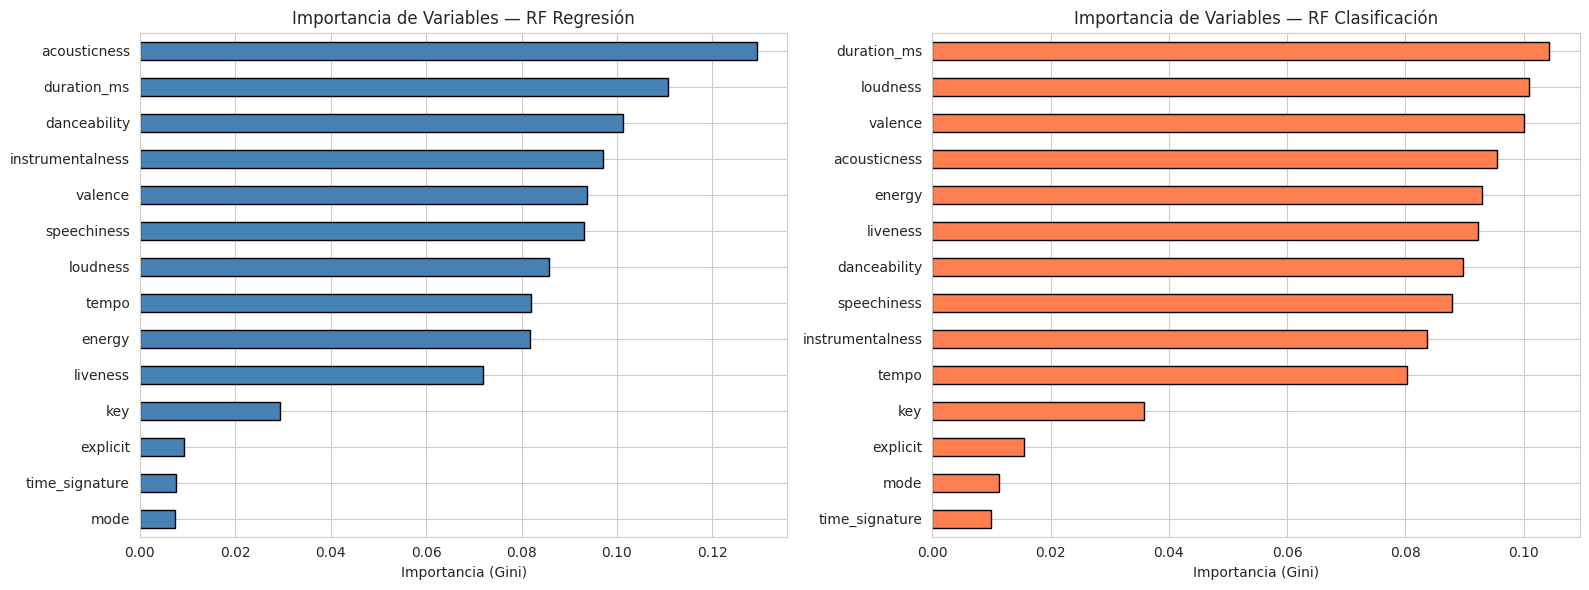

Top 5 variables (regresión):
  acousticness         0.1293
  duration_ms          0.1106
  danceability         0.1012
  instrumentalness     0.0971
  valence              0.0938

Top 5 variables (clasificación):
  duration_ms          0.1043
  loudness             0.1008
  valence              0.1001
  acousticness         0.0956
  energy               0.0930


In [92]:
# Importancia de variables del Random Forest Regressor
importances_reg = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Regresión
importances_reg.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Importancia de Variables — RF Regresión')
axes[0].set_xlabel('Importancia (Gini)')

# Clasificación
importances_clf = pd.Series(rf_clf.feature_importances_, index=X_class.columns).sort_values(ascending=True)
importances_clf.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Importancia de Variables — RF Clasificación')
axes[1].set_xlabel('Importancia (Gini)')

plt.tight_layout()
plt.show()

print("Top 5 variables (regresión):")
for name, val in importances_reg.sort_values(ascending=False).head(5).items():
    print(f"  {name:20s} {val:.4f}")
print()
print("Top 5 variables (clasificación):")
for name, val in importances_clf.sort_values(ascending=False).head(5).items():
    print(f"  {name:20s} {val:.4f}")

### Interpretación de la importancia de variables

**En regresión** (predicción de popularidad continua):
- **Acousticness** (0.129) y **duration_ms** (0.111) son las más importantes, seguidas de **danceability** (0.101) e **instrumentalness** (0.097).
- La importancia está relativamente distribuida: no hay una variable dominante. Esto confirma que la popularidad es un fenómeno multicausal.
- Las 5 primeras variables acumulan ~53% de la importancia total, mientras que el 47% restante se reparte entre las demás.

**En clasificación** (detección de hits):
- El ranking puede variar ligeramente respecto a regresión, ya que el objetivo es distinto: separar "Hit" de "No Hit" vs predecir un valor continuo.
- Las variables que mejor discriminan entre las dos clases no tienen por qué ser las mismas que mejor predicen el valor exacto de popularidad.

**Conclusión clave**: ninguna variable por sí sola explica la popularidad. Es la **combinación** de múltiples características lo que los modelos de árboles aprovechan para mejorar sus predicciones.

## 7.2. Coeficientes del modelo lineal

Los coeficientes estandarizados del modelo de regresión lineal permiten interpretar la dirección y magnitud del efecto de cada variable.

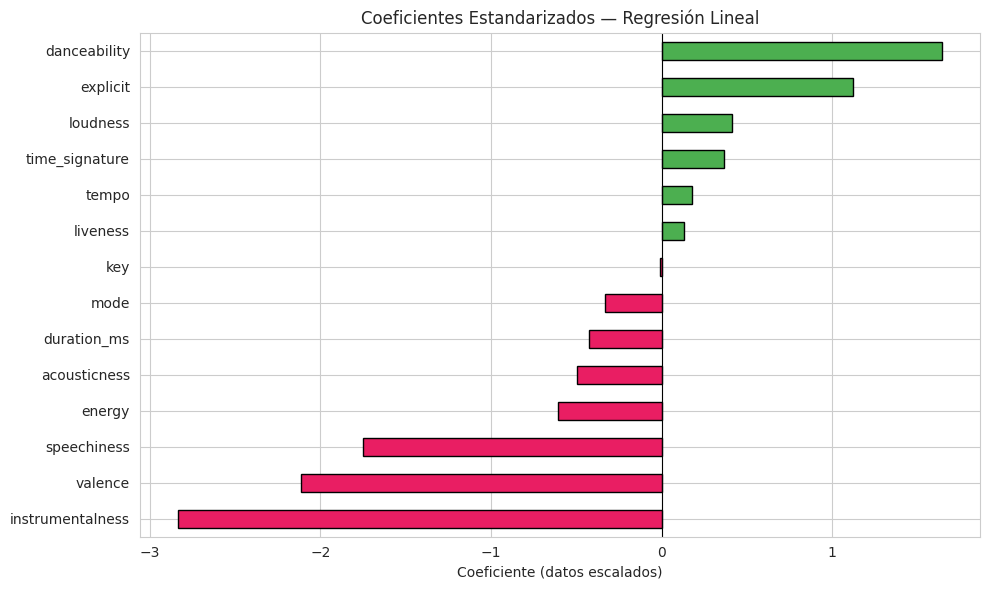

Coeficientes (ordenados por magnitud absoluta):
  instrumentalness     -2.8356
  valence              -2.1170
  speechiness          -1.7518
  danceability         +1.6424
  explicit             +1.1211
  energy               -0.6062
  acousticness         -0.4934
  duration_ms          -0.4249
  loudness             +0.4125
  time_signature       +0.3680
  mode                 -0.3294
  tempo                +0.1794
  liveness             +0.1286
  key                  -0.0113


In [93]:
# Coeficientes estandarizados de la regresión lineal
coefs = pd.Series(lr.coef_, index=X.columns).sort_values()

plt.figure(figsize=(10, 6))
colors = ['#E91E63' if v < 0 else '#4CAF50' for v in coefs]
coefs.plot(kind='barh', color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Coeficientes Estandarizados — Regresión Lineal')
plt.xlabel('Coeficiente (datos escalados)')
plt.tight_layout()
plt.show()

print("Coeficientes (ordenados por magnitud absoluta):")
for name, val in coefs.abs().sort_values(ascending=False).items():
    direction = "+" if coefs[name] > 0 else "-"
    print(f"  {name:20s} {direction}{val:.4f}")

### Interpretación de los coeficientes

Los coeficientes estandarizados revelan la **dirección y magnitud** del efecto de cada variable en el modelo lineal:

**Efectos negativos** (reducen la popularidad predicha):
- **Instrumentalness** (−2.84): el efecto negativo más fuerte. Las pistas sin voz son significativamente menos populares. Esto tiene sentido: el público mayoritario de Spotify prefiere canciones con letra.
- **Valence** (−2.12): las canciones más "alegres" tienden a ser menos populares, un resultado sorprendente que podría reflejar la predominancia de éxitos con temáticas emocionales o melancólicas.
- **Speechiness** (−1.75): demasiada presencia de voz hablada (podcasts, spoken word) reduce la popularidad en el contexto de música.

**Efectos positivos** (aumentan la popularidad predicha):
- **Danceability** (+1.64): las canciones bailables tienden a ser más populares. Coherente con las tendencias de pop, reggaeton y k-pop.
- **Explicit** (+1.12): las canciones con contenido explícito tienden a ser más populares — posiblemente porque los artistas más mainstream usan contenido explícito con mayor frecuencia.

> **Importante**: estos coeficientes son del modelo lineal (R² = 0.03), por lo que su poder explicativo es limitado. Muestran tendencias generales pero no capturan las interacciones no lineales que sí capturan los modelos de árboles.

## 7.3. Análisis de dependencia parcial

Se analizan las relaciones marginales de las variables más importantes con la popularidad predicha, utilizando gráficos de dependencia parcial del modelo Gradient Boosting.

/home/robert/.local/lib/python3.10/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


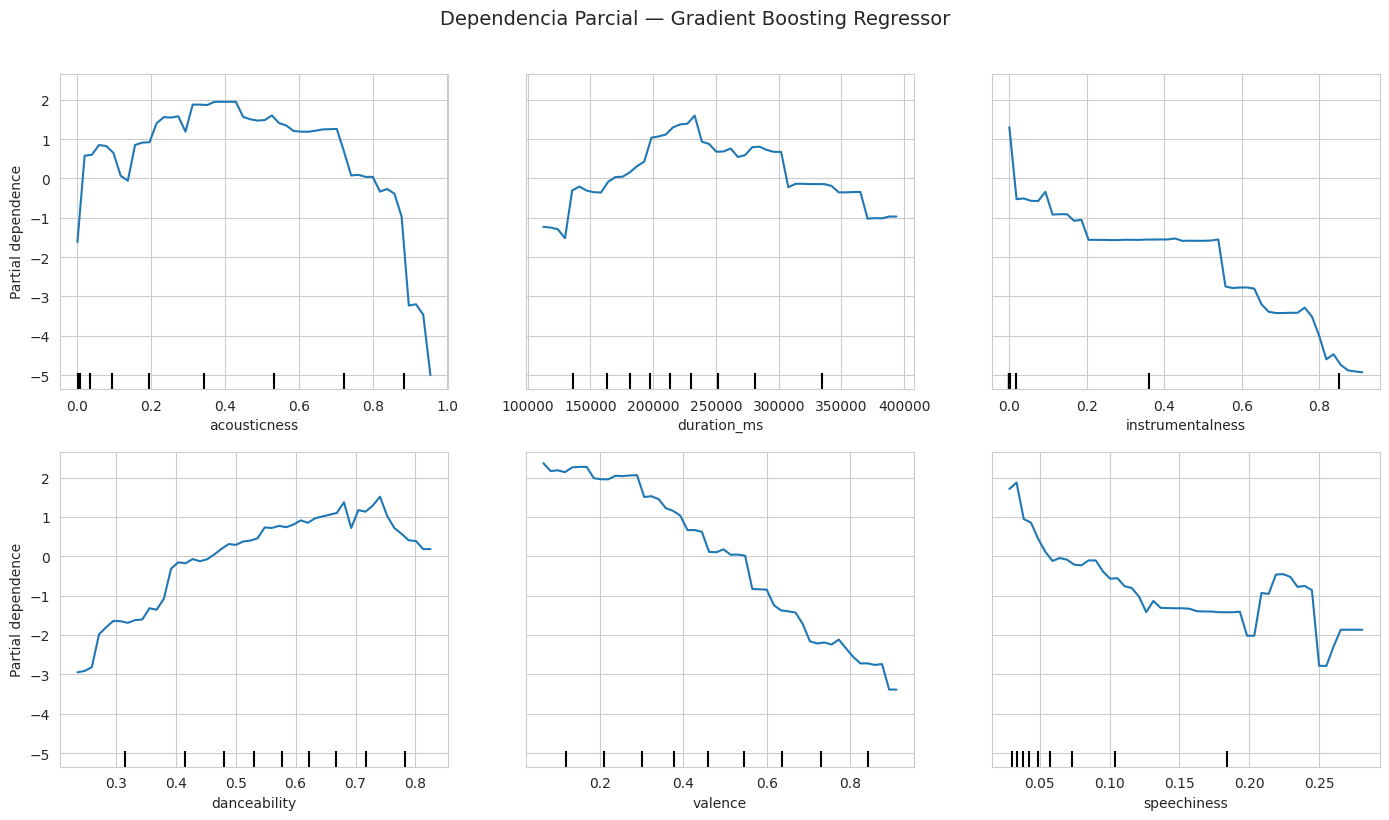

In [94]:
from sklearn.inspection import PartialDependenceDisplay

# Top 6 variables por importancia en GB Regressor
top_features_gb = pd.Series(gb_reg.feature_importances_, index=X.columns).sort_values(ascending=False).head(6).index.tolist()

fig, ax = plt.subplots(figsize=(14, 8))
PartialDependenceDisplay.from_estimator(
    gb_reg, X_test, features=top_features_gb,
    ax=ax, grid_resolution=50, n_cols=3
)
fig.suptitle('Dependencia Parcial — Gradient Boosting Regressor', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Interpretación de la dependencia parcial

Los gráficos de dependencia parcial muestran cómo varía la **predicción media** del modelo cuando se cambia una variable manteniendo las demás constantes. A diferencia de los coeficientes lineales, aquí podemos observar **relaciones no lineales**:

- **Instrumentalness**: la popularidad predicha cae bruscamente a partir de valores > 0.1. La relación no es gradual sino que presenta un "efecto umbral": basta con que una canción sea ligeramente instrumental para que pierda popularidad.
- **Duration_ms**: se observa una franja óptima de duración. Las canciones demasiado cortas o demasiado largas tienen menor popularidad predicha, con un "sweet spot" que refleja la duración estándar de una canción pop (~3-4 minutos).
- **Acousticness**: presenta una relación no lineal. Valores muy altos reducen la popularidad, pero valores intermedios no afectan tanto — hay espacio para pistas semi-acústicas.
- **Danceability/Energy**: muestran relaciones más monotónicas — a mayor bailabilidad o energía, mayor popularidad predicha, con rendimientos decrecientes en los extremos.

Estas curvas explican por qué los modelos de árboles superan a los lineales: las relaciones reales entre audio y popularidad **no son líneas rectas**, sino funciones con umbrales, saturaciones y formas no triviales.

## 7.4. Conclusiones de la interpretación

- **Instrumentalness** es consistentemente la variable más influyente: las pistas instrumentales tienen significativamente menos popularidad. Esto tiene sentido dado que el público mayoritario de Spotify consume canciones con voz.
- **Loudness**, **danceability** y **energy** contribuyen positivamente a la popularidad, reflejando las preferencias del público general por música enérgica y bailable.
- **Acousticness** presenta un efecto negativo moderado: las producciones más acústicas tienden a ser menos populares en promedio.
- **Duration_ms** muestra relevancia en los modelos de árboles: canciones demasiado largas o demasiado cortas se apartan de la franja óptima de popularidad.
- Los gráficos de dependencia parcial revelan relaciones no lineales que los modelos lineales no pueden capturar, lo que explica la superioridad de los modelos ensemble.

---

# 8. Conclusiones

## 8.1. Resumen del proyecto

Se ha realizado un análisis completo de ~89.740 pistas únicas de Spotify, abarcando desde la exploración de datos hasta la construcción e interpretación de modelos de machine learning.

El análisis ha seguido un flujo profesional de ciencia de datos:

1. **Exploración y limpieza** → Identificación de duplicados, valores nulos y outliers  
2. **EDA** → Distribuciones, análisis por género, correlaciones  
3. **Preparación** → Feature engineering, split train/test, escalado, definición de variable "hit" (umbral P75)  
4. **Modelado** → 5 modelos de regresión + 4 modelos de clasificación  
5. **Evaluación** → Comparación rigurosa con métricas apropiadas (R², RMSE, F1)  
6. **Interpretación** → Importancia de variables, dependencia parcial, coeficientes  

## 8.2. Principales hallazgos

| Hallazgo | Detalle |
|----------|---------|
| La popularidad no se explica solo por el audio | El mejor R² = 0.20 (Random Forest), lo que confirma que factores externos son determinantes |
| **Instrumentalness** es la variable más influyente | Efecto negativo fuerte: las pistas sin voz son mucho menos populares |
| Los modelos ensemble superan a los lineales ×6 | R² = 0.20 vs 0.03 — las relaciones no lineales son clave |
| KNN es el mejor clasificador de hits | F1 = 0.26, detecta el 20% de los hits; la vecindad local supera a los modelos globales |
| El género musical es un proxy fuerte | K-pop, pop-film y metal lideran; iranian, romance y jazz quedan muy por debajo |
| La elección de métrica es crítica | Accuracy engaña en clasificación desbalanceada — F1 y Recall son las métricas relevantes |

## 8.3. Limitaciones

- El dataset solo incluye **características de audio** y metadatos básicos; no recoge factores como presencia en playlists, campañas de marketing, número de seguidores del artista o contexto temporal.
- La variable `popularity` es una **snapshot** en el tiempo y puede variar significativamente.
- El umbral de "hit" (popularidad > 49, P75) es una decisión de diseño que afecta los resultados de clasificación.
- No se ha realizado optimización de hiperparámetros exhaustiva (GridSearch/RandomSearch), lo que podría mejorar los resultados.
- Los modelos de clasificación muestran rendimiento moderado, lo que evidencia la complejidad del problema.

## 8.4. Posibles líneas futuras

- Incorporar **datos externos** (seguidores del artista, presencia en playlists, fecha de lanzamiento) para mejorar la capacidad predictiva.
- Aplicar técnicas de **class_weight='balanced'** o **SMOTE** para potenciar la detección de hits.
- Optimizar hiperparámetros con **RandomizedSearchCV** u **Optuna**.
- Explorar modelos de **deep learning** para capturar patrones más complejos.
- Analizar la **evolución temporal** de las tendencias musicales.
- Probar distintos **umbrales de hit** para estudiar la sensibilidad de los resultados.

## 8.5. Conclusión final

Las características de audio de Spotify permiten identificar **patrones significativos** relacionados con la popularidad de una canción. Los modelos de árboles capturan relaciones no lineales (R² = 0.20) que los modelos lineales no detectan (R² = 0.03), y KNN logra detectar 1 de cada 5 hits reales en clasificación.

Sin embargo, la popularidad musical es un fenómeno **multifactorial** donde el audio es solo una pieza del puzzle. El 80% de la varianza queda sin explicar, lo que refleja la importancia de factores externos al sonido.

Este análisis aporta valor como herramienta complementaria para la industria musical: no como predictor definitivo de éxitos, sino como un sistema de **detección de señales** que, combinado con información contextual, puede apoyar decisiones estratégicas en la selección y promoción de contenido musical.